In [ ]:
# EDA — Train uniquement

Ce notebook explore exclusivement le segment TRAIN :

- steps 1 à 323 ;
- 4 463 587 transactions ;
- aucune consultation de Validation ;
- aucune consultation du Test final.

## Objectifs

1. vérifier la qualité du jeu de travail ;
2. comprendre le déséquilibre ;
3. identifier les comportements associés à la fraude ;
4. formuler des hypothèses de features pré-transaction ;
5. identifier les risques d'artefacts propres à PaySim.

## Règle anti-fuite

Les variables post-transaction ne sont pas utilisées pour concevoir le modèle :

- `newbalance_orig`
- `newbalance_dest`
- toute variable dérivée de ces colonnes.

Les observations réalisées ici devront ensuite être testées sur Validation.

In [2]:
from pathlib import Path

CURRENT = Path.cwd()

if (CURRENT / "data").exists():
    ROOT = CURRENT
else:
    ROOT = CURRENT.parent

TRAIN_PATH = ROOT / "data" / "processed" / "train.parquet"

assert TRAIN_PATH.exists(), f"Fichier introuvable : {TRAIN_PATH}"

TRAIN_PATH

WindowsPath('C:/Users/Emmanuel/Documents/Professionnel/Formations/DIT/fraude-mobile-money/data/processed/train.parquet')

In [3]:
# Chargement des colonnes utiles
core_columns = [
    "step",
    "type",
    "amount",
    "oldbalance_org",
    "oldbalance_dest",
    "is_fraud",
]

df = pd.read_parquet(
    TRAIN_PATH,
    columns=core_columns,
)

df.shape

(4463587, 6)

In [5]:
# Vérifications structurelles
assert len(df) == 4_463_587
assert df["step"].min() == 1
assert df["step"].max() == 323

assert set(df["is_fraud"].unique()).issubset({0, 1})

assert df.isna().sum().sum() == 0

assert (df["amount"] >= 0).all()
assert (df["oldbalance_org"] >= 0).all()
assert (df["oldbalance_dest"] >= 0).all()

print("Contrôles structurels TRAIN : OK")

Contrôles structurels TRAIN : OK


In [ ]:
df.info(memory_usage="deep")

In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
step,"4,463,587.0000",NaN,NaN,NaN,174.0518,96.0550,1.0000,130.0000,186.0000,253.0000,323.0000
type,4463587,5,CASH_OUT,1582647,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amount,"4,463,587.0000",NaN,NaN,NaN,"174,802.2720","623,805.9386",0.0000,"12,830.5800","75,005.9500","208,314.2200","92,445,516.6400"
oldbalance_org,"4,463,587.0000",NaN,NaN,NaN,"840,004.4820","2,912,230.7158",0.0000,0.0000,"14,222.0400","108,233.0000","43,818,855.3000"
oldbalance_dest,"4,463,587.0000",NaN,NaN,NaN,"1,036,872.2597","2,846,950.8860",0.0000,0.0000,"135,280.9700","940,707.8250","324,915,061.4100"
is_fraud,"4,463,587.0000",NaN,NaN,NaN,0.0008,0.0286,0.0000,0.0000,0.0000,0.0000,1.0000


In [9]:
# Prévalence de la fraude
n_total = len(df)
n_fraud = int(df["is_fraud"].sum())
fraud_rate = df["is_fraud"].mean()

print(f"Transactions : {n_total:,}")
print(f"Fraudes      : {n_fraud:,}")
print(f"Taux fraude  : {fraud_rate:.6%}")

Transactions : 4,463,587
Fraudes      : 3,643
Taux fraude  : 0.081616%


,transactions,part
is_fraud,,
0,4459944,0.9992
1,3643,0.0008


In [8]:
class_counts = (
    df["is_fraud"]
    .value_counts()
    .rename_axis("is_fraud")
    .to_frame("transactions")
)

class_counts["part"] = (
    class_counts["transactions"] / len(df)
)

class_counts

,transactions,part
is_fraud,,
0,4459944,0.9992
1,3643,0.0008


In [ ]:
# Conclusion

La fraude représente moins de 0,1 % du Train. L'accuracy ne constitue donc pas une métrique pertinente pour juger un détecteur. Une prédiction systématique de la classe légitime obtiendrait une accuracy très élevée tout en détectant zéro fraude

In [10]:
# Fraude par type
fraud_by_type = (
    df.groupby("type", observed=True)
    .agg(
        transactions=("is_fraud", "size"),
        fraudes=("is_fraud", "sum"),
    )
)

fraud_by_type["taux_fraude"] = (
    fraud_by_type["fraudes"]
    / fraud_by_type["transactions"]
)

fraud_by_type.sort_values(
    "transactions",
    ascending=False,
)

,transactions,fraudes,taux_fraude
type,,,
CASH_OUT,1582647,1831,0.0012
PAYMENT,1506552,0,0.0000
CASH_IN,977376,0,0.0000
TRANSFER,369248,1812,0.0049
DEBIT,27764,0,0.0000


In [11]:
fraud_types = fraud_by_type.query(
    "fraudes > 0"
)

fraud_types

,transactions,fraudes,taux_fraude
type,,,
CASH_OUT,1582647,1831,0.0012
TRANSFER,369248,1812,0.0049


In [14]:
# Distribution des montants
amount_stats = (
    df.groupby("is_fraud")["amount"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        min="min",
        max="max",
    )
)

amount_stats

,count,mean,median,min,max
is_fraud,,,,,
0,4459944,"173,828.2810","74,882.5850",0.0200,"92,445,516.6400"
1,3643,"1,367,211.1727","417,217.8900",0.0000,"10,000,000.0000"


In [15]:
# Les quantiles
df.groupby("is_fraud")["amount"].quantile(
    [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).unstack(0)

is_fraud,0,1
0.2500,"12,817.7875","117,345.3500"
0.5000,"74,882.5850","417,217.8900"
0.7500,"208,095.8175","1,516,823.7300"
0.9000,"363,141.6260","3,928,110.9480"
0.9500,"508,496.2255","7,114,590.0700"
0.9900,"1,436,098.1072","10,000,000.0000"


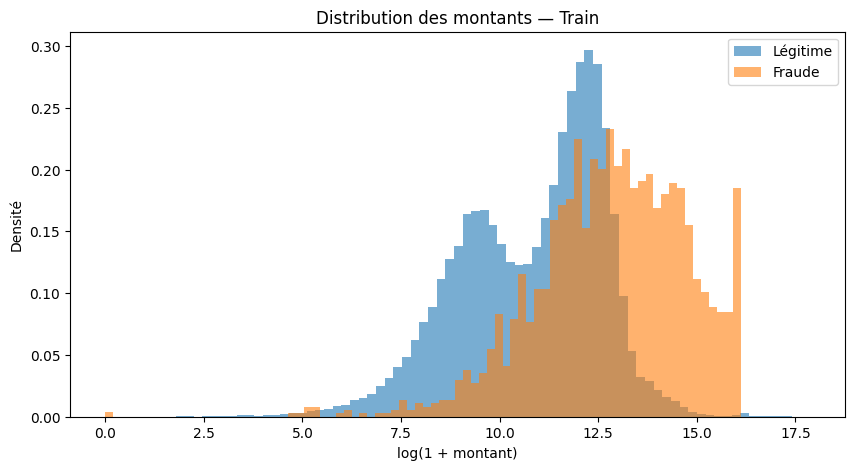

In [16]:
# Visualisation des montants
sample_legit = df.loc[
    df["is_fraud"] == 0,
    "amount"
].sample(
    n=min(100_000, (df["is_fraud"] == 0).sum()),
    random_state=42,
)

fraud_amounts = df.loc[
    df["is_fraud"] == 1,
    "amount"
]

plt.figure(figsize=(10, 5))

plt.hist(
    np.log1p(sample_legit),
    bins=80,
    alpha=0.6,
    density=True,
    label="Légitime",
)

plt.hist(
    np.log1p(fraud_amounts),
    bins=80,
    alpha=0.6,
    density=True,
    label="Fraude",
)

plt.xlabel("log(1 + montant)")
plt.ylabel("Densité")
plt.title("Distribution des montants — Train")
plt.legend()

plt.show()

In [17]:
# Baseline conceptuelle « gros montant »
ranked_amount = (
    df[["amount", "is_fraud"]]
    .sort_values(
        "amount",
        ascending=False,
    )
    .reset_index(drop=True)
)

for k in [100, 500, 1000, 5000, 10000]:
    top = ranked_amount.head(k)

    precision = top["is_fraud"].mean()
    recall = (
        top["is_fraud"].sum()
        / df["is_fraud"].sum()
    )

    print(
        f"K={k:>5,} | "
        f"Precision={precision:.2%} | "
        f"Recall={recall:.2%}"
    )

K=  100 | Precision=0.00% | Recall=0.00%
K=  500 | Precision=0.00% | Recall=0.00%
K=1,000 | Precision=0.00% | Recall=0.00%
K=5,000 | Precision=2.88% | Recall=3.95%
K=10,000 | Precision=4.45% | Recall=12.22%


In [18]:
# Solde émetteur avant transaction
balance_stats = (
    df.groupby("is_fraud")["oldbalance_org"]
    .agg(
        mean="mean",
        median="median",
        min="min",
        max="max",
    )
)

balance_stats

,mean,median,min,max
is_fraud,,,,
0,"839,504.6275","14,135.0000",0.0000,"43,818,855.3000"
1,"1,451,951.4933","415,437.2700",0.0000,"37,670,038.0800"


In [19]:
df.groupby("is_fraud")["oldbalance_org"].quantile(
    [0.25, 0.50, 0.75, 0.90, 0.99]
).unstack(0)

is_fraud,0,1
0.2500,0.0000,"114,169.6600"
0.5000,"14,135.0000","415,437.2700"
0.7500,"107,877.2500","1,516,057.4600"
0.9000,"1,800,110.3100","3,928,110.9480"
0.9900,"16,258,891.6509","10,930,025.9700"


In [21]:
# Hypothèse du vidage du compte
df["initial_balance_zero"] = (
    df["oldbalance_org"] == 0
).astype("int8")

df["ratio_amount_balance"] = np.where(
    df["oldbalance_org"] > 0,
    df["amount"] / df["oldbalance_org"],
    np.nan,
)

In [22]:
# Mesurer la proximité d'un vidage
df["ecart_vidage"] = np.where(
    df["oldbalance_org"] > 0,
    np.abs(
        df["amount"] / df["oldbalance_org"] - 1
    ),
    np.nan,
)

In [23]:
df.groupby("is_fraud")["ecart_vidage"].describe(
    percentiles=[
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99,
    ]
)

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
is_fraud,,,,,,,,,,,
0,"2,978,617.0000",117.1216,"4,006.9929",0.0000,0.8110,0.9802,5.5486,37.2786,169.4820,"1,655.4998","3,925,474.6000"
1,"3,615.0000",0.0186,0.5731,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.1840,28.5266


In [24]:
thresholds = [
    0.001,
    0.01,
    0.05,
    0.10,
]

for eps in thresholds:
    near_empty = (
        df["ecart_vidage"] <= eps
    )

    table = pd.crosstab(
        df["is_fraud"],
        near_empty,
        normalize="index",
    )

    print(f"\nε = {eps}")
    display(table)


ε = 0.001


ecart_vidage,False,True
is_fraud,,
0,0.9999,0.0001
1,0.0209,0.9791



ε = 0.01


ecart_vidage,False,True
is_fraud,,
0,0.9985,0.0015
1,0.0209,0.9791



ε = 0.05


ecart_vidage,False,True
is_fraud,,
0,0.9924,0.0076
1,0.0200,0.9800



ε = 0.1


ecart_vidage,False,True
is_fraud,,
0,0.9848,0.0152
1,0.0192,0.9808


In [ ]:
PaySim encode un comportement de fraude fortement associé au prélèvement d’une grande partie du solde disponible.

In [25]:
# Baseline ecart_vidage
for eps in [
    0.001,
    0.005,
    0.01,
    0.05,
    0.10,
]:

    pred = (
        df["ecart_vidage"] <= eps
    )

    tp = (
        (pred)
        & (df["is_fraud"] == 1)
    ).sum()

    fp = (
        (pred)
        & (df["is_fraud"] == 0)
    ).sum()

    fn = (
        (~pred)
        & (df["is_fraud"] == 1)
    ).sum()

    precision = (
        tp / (tp + fp)
        if (tp + fp) else 0
    )

    recall = (
        tp / (tp + fn)
        if (tp + fn) else 0
    )

    print(
        f"ε={eps:<6} | "
        f"Precision={precision:.2%} | "
        f"Recall={recall:.2%} | "
        f"Alertes={tp + fp:,}"
    )

ε=0.001  | Precision=84.87% | Recall=97.91% | Alertes=4,203
ε=0.005  | Precision=51.43% | Recall=97.91% | Alertes=6,935
ε=0.01   | Precision=34.81% | Recall=97.91% | Alertes=10,246
ε=0.05   | Precision=9.51% | Recall=98.00% | Alertes=37,530
ε=0.1    | Precision=5.01% | Recall=98.08% | Alertes=71,317


In [27]:
# Solde du destinataire avant transaction
dest_stats = (
    df.groupby("is_fraud")["oldbalance_dest"]
    .agg(
        mean="mean",
        median="median",
        min="min",
        max="max",
    )
)

dest_stats

Solde du destinataire avant transaction


,mean,median,min,max
is_fraud,,,,
0,"1,037,349.1952","135,669.5950",0.0000,"324,915,061.4100"
1,"452,983.8413",0.0000,0.0000,"32,961,658.2500"


In [28]:
df["dest_balance_zero"] = (
    df["oldbalance_dest"] == 0
)

pd.crosstab(
    df["is_fraud"],
    df["dest_balance_zero"],
    normalize="index",
)

dest_balance_zero,False,True
is_fraud,,
0,0.5775,0.4225
1,0.3541,0.6459


In [29]:
# Structure temporelle du Train
fraud_by_step = (
    df.groupby("step")
    .agg(
        transactions=("is_fraud", "size"),
        fraudes=("is_fraud", "sum"),
    )
)

fraud_by_step["taux_fraude"] = (
    fraud_by_step["fraudes"]
    / fraud_by_step["transactions"]
)

fraud_by_step.head()

,transactions,fraudes,taux_fraude
step,,,
1,2708,16,0.0059
2,1014,8,0.0079
3,552,4,0.0072
4,565,10,0.0177
5,665,6,0.0090


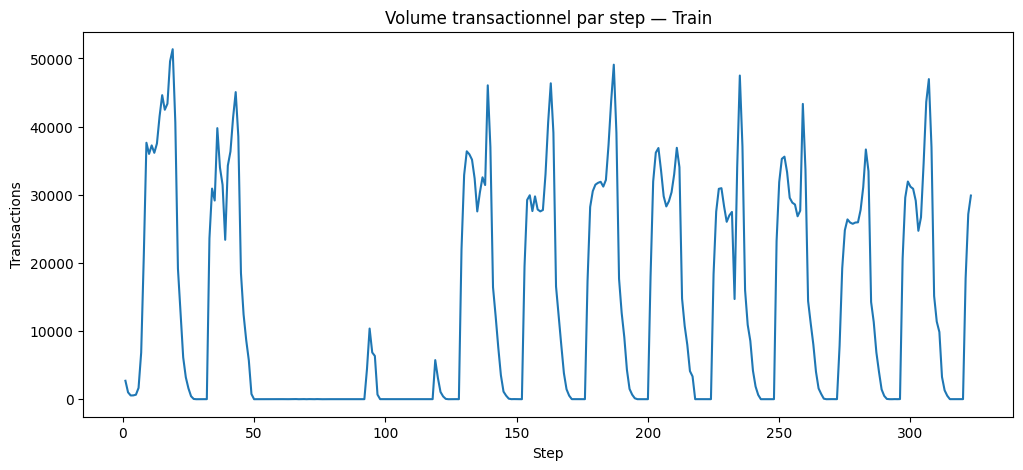

In [30]:
# Graphique
plt.figure(figsize=(12, 5))

plt.plot(
    fraud_by_step.index,
    fraud_by_step["transactions"],
)

plt.xlabel("Step")
plt.ylabel("Transactions")
plt.title("Volume transactionnel par step — Train")

plt.show()

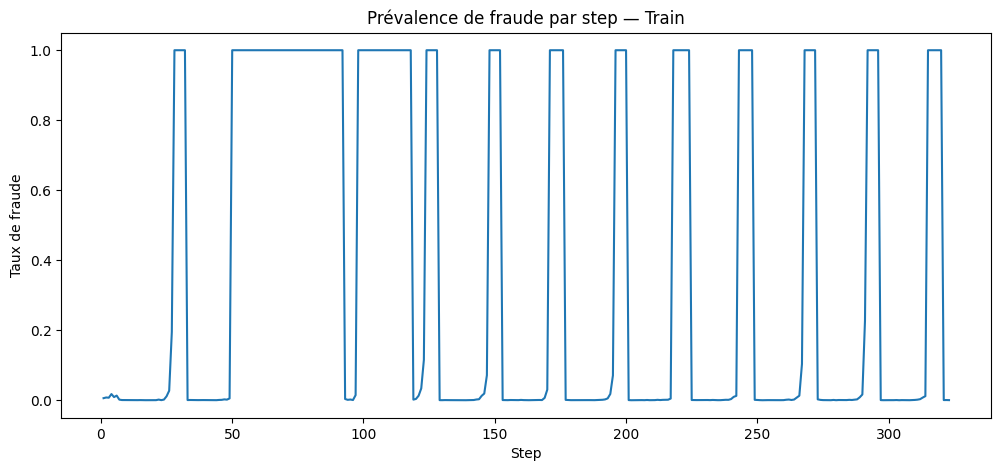

In [31]:
# Taux de fraude
plt.figure(figsize=(12, 5))

plt.plot(
    fraud_by_step.index,
    fraud_by_step["taux_fraude"],
)

plt.xlabel("Step")
plt.ylabel("Taux de fraude")
plt.title("Prévalence de fraude par step — Train")

plt.show()

In [32]:
#Repérer les steps anormaux
fraud_by_step.sort_values(
    "taux_fraude",
    ascending=False,
).head(20)

,transactions,fraudes,taux_fraude
step,,,
87,6,6,1.0000
74,22,22,1.0000
223,8,8,1.0000
98,14,14,1.0000
99,8,8,1.0000
100,6,6,1.0000
101,12,12,1.0000
102,12,12,1.0000
103,8,8,1.0000


In [33]:
# step % 24
df["phase_24h"] = (
    df["step"] % 24
).astype("int8")

phase_stats = (
    df.groupby("phase_24h")
    .agg(
        transactions=("is_fraud", "size"),
        fraudes=("is_fraud", "sum"),
    )
)

phase_stats["taux_fraude"] = (
    phase_stats["fraudes"]
    / phase_stats["transactions"]
)

phase_stats

,transactions,fraudes,taux_fraude
phase_24h,,,
0,49723,116,0.0023
1,20464,170,0.0083
2,6047,158,0.0261
3,1065,126,0.1183
4,665,110,0.1654
5,803,144,0.1793
6,1788,150,0.0839
7,6975,150,0.0215
8,21251,166,0.0078


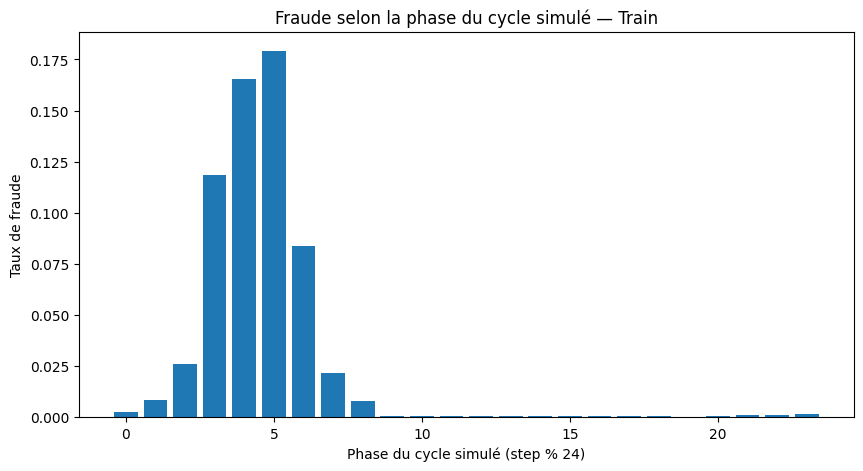

In [34]:
plt.figure(figsize=(10, 5))

plt.bar(
    phase_stats.index,
    phase_stats["taux_fraude"],
)

plt.xlabel("Phase du cycle simulé (step % 24)")
plt.ylabel("Taux de fraude")
plt.title("Fraude selon la phase du cycle simulé — Train")

plt.show()

In [35]:
# Identifiants
ids = pd.read_parquet(
    TRAIN_PATH,
    columns=[
        "name_orig",
        "name_dest",
        "is_fraud",
    ],
)


In [36]:
print(
    "Émetteurs uniques :",
    ids["name_orig"].nunique(),
)

print(
    "Destinataires uniques :",
    ids["name_dest"].nunique(),
)

Émetteurs uniques : 4458949
Destinataires uniques : 1905776


In [37]:
# Fréquence
orig_freq = (
    ids["name_orig"]
    .value_counts()
)

dest_freq = (
    ids["name_dest"]
    .value_counts()
)

orig_freq.describe()

count   4,458,949.0000
mean            1.0010
std             0.0323
min             1.0000
25%             1.0000
50%             1.0000
75%             1.0000
max             3.0000
Name: count, dtype: float64

In [38]:
dest_freq.describe()

count   1,905,776.0000
mean            2.3421
std             4.5221
min             1.0000
25%             1.0000
50%             1.0000
75%             1.0000
max           108.0000
Name: count, dtype: float64

In [39]:
# Vérification
print(
    "Part d'émetteurs vus plusieurs fois :",
    (orig_freq > 1).mean(),
)

print(
    "Part de destinataires vus plusieurs fois :",
    (dest_freq > 1).mean(),
)

Part d'émetteurs vus plusieurs fois : 0.0010390340862835613
Part de destinataires vus plusieurs fois : 0.16919564523847502


In [ ]:
Les comptes se répètent suffisamment, cela ouvre la voie à des features plus réalistes

In [40]:
zero_balance_analysis = (
    df.groupby("is_fraud")
    .agg(
        transactions=("is_fraud", "size"),
        solde_initial_nul=(
            "initial_balance_zero",
            "sum",
        ),
    )
)

zero_balance_analysis["part_solde_initial_nul"] = (
    zero_balance_analysis["solde_initial_nul"]
    / zero_balance_analysis["transactions"]
)

zero_balance_analysis

,transactions,solde_initial_nul,part_solde_initial_nul
is_fraud,,,
0,4459944,1481327,0.3321
1,3643,28,0.0077


In [ ]:
# Synthèse

## Constats confirmés

### Déséquilibre
- ...

### Types de transaction
- ...

### Montants
- ...

### Comportement relatif au solde émetteur
- ...

### Solde destinataire
- ...

### Structure temporelle
- ...

### Identifiants / historique
- ...

---

## Hypothèses de features pour la Phase 5

À tester :

- ...
- ...
- ...

---

## Risques identifiés

- artefacts spécifiques à PaySim ;
- dépendance excessive au comportement de vidage ;
- signal temporel potentiellement non généralisable ;
- faible prévalence ;
- évolution temporelle de la fraude.

---

## Variables explicitement exclues

- newbalance_orig
- newbalance_dest
- is_flagged_fraud
- toute feature dérivée d'une information post-transaction

In [44]:
ids = pd.read_parquet(
    TRAIN_PATH,
    columns=[
        "name_orig",
        "name_dest",
        "is_fraud",
    ],
)

orig_freq = ids["name_orig"].value_counts()
dest_freq = ids["name_dest"].value_counts()

print("Émetteurs uniques :", ids["name_orig"].nunique())
print("Destinataires uniques :", ids["name_dest"].nunique())

print()
print("Fréquence émetteurs")
display(orig_freq.describe())

print()
print("Fréquence destinataires")
display(dest_freq.describe())

print()
print(
    "Émetteurs vus plusieurs fois :",
    f"{(orig_freq > 1).mean():.2%}"
)

print(
    "Destinataires vus plusieurs fois :",
    f"{(dest_freq > 1).mean():.2%}"
)

Émetteurs uniques : 4458949
Destinataires uniques : 1905776

Fréquence émetteurs


count   4,458,949.0000
mean            1.0010
std             0.0323
min             1.0000
25%             1.0000
50%             1.0000
75%             1.0000
max             3.0000
Name: count, dtype: float64


Fréquence destinataires


count   1,905,776.0000
mean            2.3421
std             4.5221
min             1.0000
25%             1.0000
50%             1.0000
75%             1.0000
max           108.0000
Name: count, dtype: float64


Émetteurs vus plusieurs fois : 0.10%
Destinataires vus plusieurs fois : 16.92%
